## SMBHB model 
This notebook provides the photometric model of Super Massive Black Hole Binaries for two components: 
- Stochastic Quasar Variability
- Doppler boosting
- Gravitational self-lensing

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy import units as u
from astropy import constants as c
from ipywidgets import *

# PlatoSim libraries
import platosim.utilities as ut
import platosim.plot      as pt
import platosim.noise     as ns
from platosim.varsource    import SMBHB
from platosim.lightcurve   import LightCurve
from platosim.slurm        import workerOverview
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [3]:
# Paths to where data is stored
path = '/lhome/nicholas/software/workdir/smbhb'
fdir = '/lhome/nicholas/Nextcloud/paperSMBHB/figures'

---
## Physical model
---

### Example: Model Spikey 
Finally we define our constants and parameters of the SPIKEY SMBHB. We also define the time series here and convert necessary units from (seconds) to Modified Julian Date for a better comparison with the light curve produced by Hu et.al  

### Grantional lensing

In [ ]:
# Initialise model
dt   = 25
tdur = ut.year() * 5
time = np.arange(0, tdur, dt) * u.s                          
model = SMBHB(time, seed=12345)

In [91]:
# Parameters relating to Spikey
z  = 0.962
P  = 1.144 * u.yr
t0  = 100 / 365.25 * u.yr
M1 = 10**7.4 * u.M_sun                                                           
M2 = 10**6.7 * u.M_sun
M  = (M1 + M2)
q  = (M2 / M1)
I  = np.arccos(0.140) * u.rad
i  = I - np.pi/2 * u.rad
J  = np.pi / 4 * u.rad

# Eccentric orbits
e  = 0.524
w  = 1.477 * u.rad
alpha = 2.09
F_lum = 0.89

Model parameters:
Orbital period in rest frame, P    : 1.144 yr
Orbital period in obs. frame, T    : 2.245 yr
Mass total, M = (M1 + M2)          : 30.131 solMass x 1e6
Mass ratio, q = (M2 / M1)          : 0.1995
Inclination of orbits, I           : 81.95 deg
Inclination of mini-disc, J        : 45.00 deg
Semi-major axis of binaries, a     : 340.37 AU
Schwarchild radius primary, Rs1    : 106.63 solRad
Schwarchild radius secondary, Rs2  : 21.28 solRad
Max Einstein radius primary, Re1   : 18.37 AU
Max Einstein radius secondary, Re2 : 8.21 AU


100%|██████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 704.84it/s]                                                                                                                

2226 2226


<IPython.core.display.Javascript object>


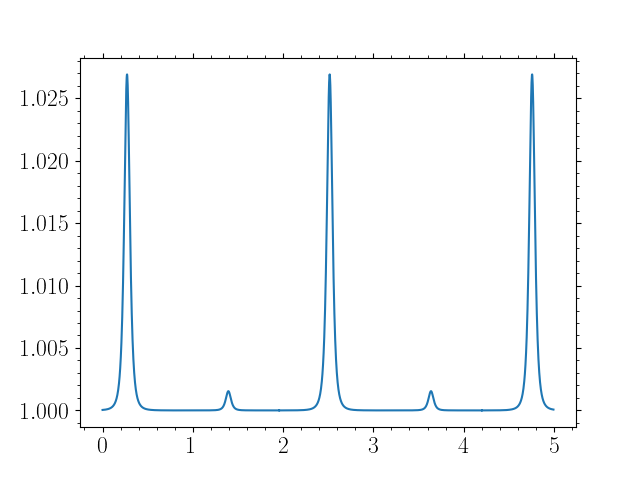

ValueError: Expect x to not have duplicates

In [110]:
flux_lens = model.gravitational_lensing(t0, z, P, M, q, I, J, wvl=550, u_max=10, u_grid=100, v_grid=100)

<IPython.core.display.Javascript object>


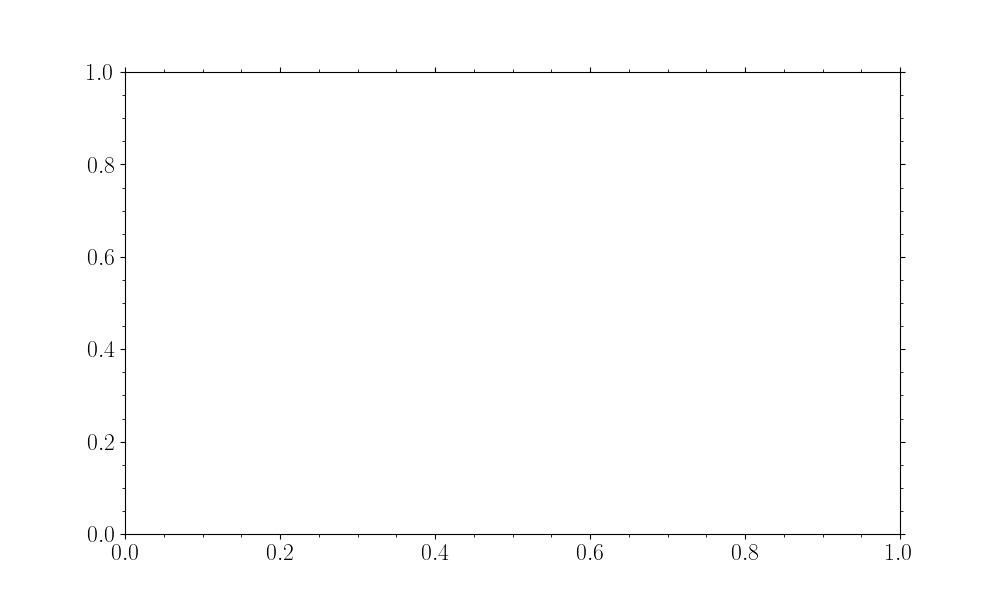

ValueError: x and y must have same first dimension, but have shapes (6311386,) and (2226,)

In [111]:
plt.figure(figsize=(10,6))
plt.plot(time, flux_lens, '-',  c='royalblue', label='Point')
# plt.plot(time, M_finit, '--', c=cols[2], label='Finite')
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.title(f'Parameters: q = {q:.2f}, I = {np.rad2deg(I):.2f}°, J = {np.rad2deg(J):.2f}°')
plt.xlim(0, time.to('d').value[-1])
plt.legend()
plt.tight_layout()

In [7]:
# # Lensing events
# A1, A2, A = model.gravitational_lensing(t0, P, M1, M2, I, J, z)
# # flux_lens = (1 - flux_lum) * A1 + flux_lum * A2

# time = time.to('d')[::10000]
# fig = plt.figure(figsize = (8, 4))
# plt.plot(time, A1,        ':',  c='orange', label=r"$A_1$")
# plt.plot(time, A2,        '-.', c='orange', label=r"$A_2$")
# plt.plot(time, A,        '-', c='orange', label=r"$A$")
# # plt.plot(time.to('d'), flux_lens, '-',  c='orange', label=r"Lensing")
# # plt.plot(A1,        '-', c='orange', label=r"$A$")
# # plt.plot(A2,        '-', c='orange', label=r"$A$")

# # phi = np.linspace(0, 2*np.pi, len(time))
# # plt.plot(phi, A1,        ':',  c='orange', label=r"$A_1$")
# # plt.plot(phi, A2,        '-.', c='orange', label=r"$A_2$")
# # plt.plot(phi, flux_lens, '-',  c='orange', label=r"Lensing")

# plt.xlabel(r"Time [day]")
# plt.ylabel(r"Relative flux")
# # plt.xlim(0, time.to('d').value[-1])
# plt.legend()
# plt.tight_layout()

In [75]:
# dx = pd.read_feather(f'{path}/lensing_model.ftr')

# time0 = np.arange(0, t0.value, 25)
# time1 = np.arange(t0.value, t0.value+25*dx.shape[0], 25)
# time2 = np.arange(t0.value+25*dx.shape[0], tdur, 25)
# time_lens = np.concatenate((time0, time1, time2))

# flux0 = time0 * 0
# flux1 = (dx.flux-dx.flux.min()) / 14
# flux2 = time2 * 0
# flux_lens = np.concatenate((flux0, flux1, flux2)) + 1

# fig = plt.figure()
# plt.plot(time_lens, flux_lens);

### Doppler boosting

In [80]:
# Construct time array
D1, D2 = model.doppler_boosting(z, t0, P, M1, M2, i, e, w, alpha)
flux_beam = (1 - F_lum) * D1**(3 - alpha) + F_lum * D2**(3 - alpha)
flux_beam = (flux_beam - 1)*2 + 1

<IPython.core.display.Javascript object>


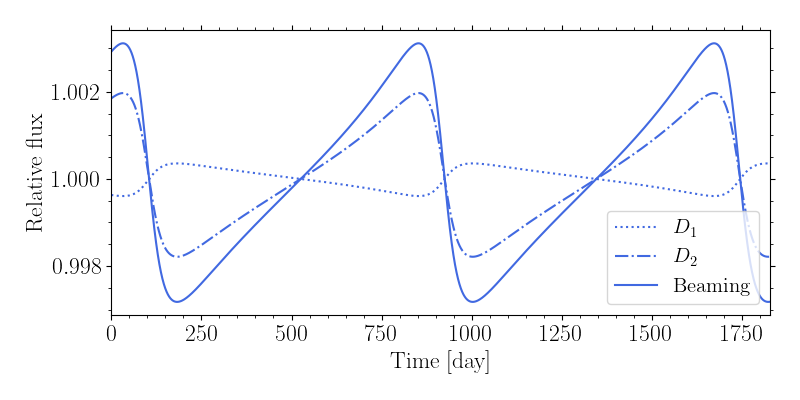

In [81]:
fig = plt.figure(figsize = (9, 4))
plt.plot(time.to('d'), D1,       ':',  c='orange', label=r"$D_1$")
plt.plot(time.to('d'), D2,       '-.', c='orange', label=r"$D_2$")
plt.plot(time.to('d'), flux_beam, '-', c='orange', label=r"Beaming")
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.xlim(0, time.to('d').value[-1])
plt.legend()
plt.tight_layout()

### QSO variability (red noise)

In [82]:
tau   = np.array([50]) * u.d
sigma = np.array([30]) # ppm
flux_red = model.quasar_variability(tau, sigma)

<IPython.core.display.Javascript object>


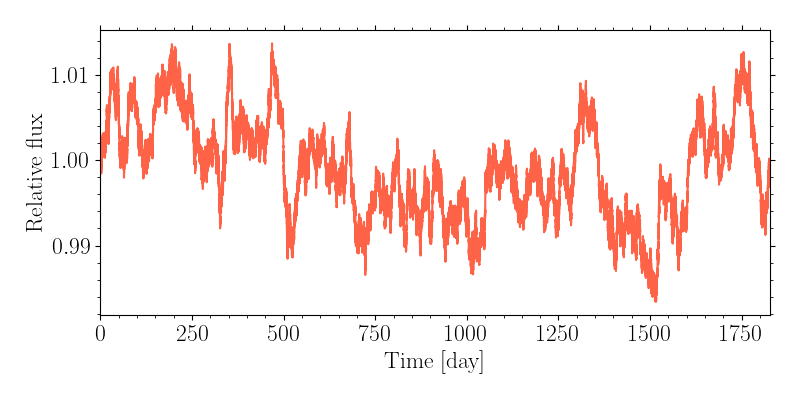

In [83]:
fig = plt.figure(figsize = (8, 4))
plt.plot(time.to('d'), flux_red, color='tomato')
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.xlim(0, time.to('d').value[-1])
plt.tight_layout()

<IPython.core.display.Javascript object>


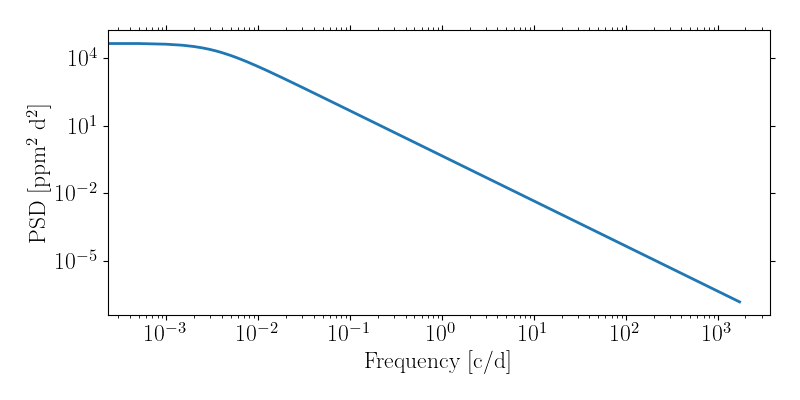

In [10]:
Nfreq = time.shape[0]
freq = np.arange(float(Nfreq)) / (Nfreq-1) * 0.5 / (dt * u.s).to('d').value
PSD = ns.modelRedNoisePSD(freq, tau.to('d').value, sigma)

fig = plt.figure(figsize = (8, 4))
for i in range(len(tau)):
    plt.loglog(freq, PSD, lw=2)
plt.xlabel(r"Frequency [c/d]")
plt.ylabel(r"PSD [ppm$^2$ d$^2$]")
plt.tight_layout()
plt.show()

### Combined model

In [86]:
# Combined model (Beaming + QSO varibility)
flux = flux_beam * flux_red * flux_lens

# Plotting the combined (Doppler + Stochastic Quasar Variability) model
fig = plt.figure(figsize = (9, 5))
# plt.plot(time.to('d'), np.ones_like(time), '--', c='k')
plt.plot(time.to('d'), flux_red,  color='tomato',    label="DRW",     lw=0.8)
plt.plot(time.to('d'), flux_beam, color='orange',    label="Beaming", lw=2)
plt.plot(time.to('d'), flux_lens, color='royalblue', label="Lensing", lw=2)
plt.plot(time.to('d'), flux,      color='k',         label="Combined", lw=0.8)
plt.xlabel(r"Time [day]")
plt.ylabel(r"Relative flux")
plt.xlim(0, time.to('d').value[-1])
plt.legend()
plt.tight_layout()

# Save figure
# fig.savefig(f'{fdir}/spikey_model.png', bbox_inches='tight', dpi=300)

TypeError: unsupported operand type(s) for *: 'float' and 'NoneType'

In [105]:
# Save Spikey varsource file for PlatoSim
ofile = f'{path}/input/varsource_spikey.txt'
data = np.transpose([time, -2.5*np.log10(flux)])
# np.savetxt(ofile, data, fmt=['%.1f', '%.8f'])

<IPython.core.display.Javascript object>


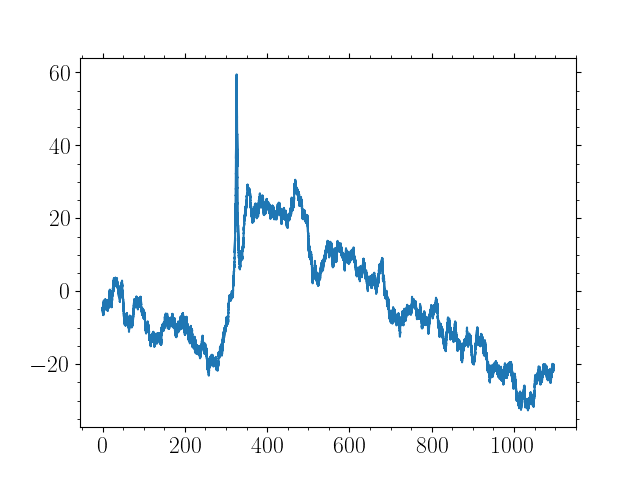

In [107]:
plt.figure()
# plt.plot(data[:,0], data[:,1])
plt.plot(time/86400, (flux-1)*1e3)

In [1]:
# # PLOT FOR THESIS COVER
# # Combined model (Beaming + QSO varibility)
# flux = flux_beam * flux_red * flux_lens
# # Plotting the combined model
# fig = plt.figure(figsize=(3.18,1.6))
# plt.plot(time.to('d'), flux, color='w', lw=0.8)
# plt.xlim(0, time.to('d').value[-1])
# plt.tight_layout()
# plt.xticks([])
# plt.yticks([])
# plt.axis('off')
# # Save figure
# tdir = '/lhome/nicholas/Nextcloud/thesis/image'
# fig.savefig(f'{tdir}/lightcurve_smbhb.png', bbox_inches='tight', dpi=300, transparent=True)